In [4]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Locate the absolute root path of your project workspace
root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 2. Define the two primary possible paths for your survey data
possible_paths = [
    os.path.join(root_dir, 'data', 'group17_clean.csv'),
    os.path.join(root_dir, 'data', 'raw', 'group17_sti_survey_raw.csv'),
    os.path.join(os.getcwd(), 'data', 'group17_clean.csv') # Fallback check
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✅ DATA ARCHITECTURE SECURED:")
        print(f"Successfully loaded dataset from: {os.path.basename(path)}")
        break

# 3. Clean and normalize column headers if dataset loaded successfully
if df is not None:
    df.columns = (
        df.columns.str.lower()
        .str.strip()
        .str.replace(r'[\s/\\\-]+', '_', regex=True)
        .str.replace(r'[()’\'?*.]', '', regex=True)
    )
    print(f"Matrix Dimensions: {df.shape[0]} respondents × {df.shape[1]} clinical metrics.")
else:
    print("❌ CRITICAL ERROR: Could not find the CSV file. Please verify the filename inside your 'data' folder.")

✅ DATA ARCHITECTURE SECURED:
Successfully loaded dataset from: group17_sti_survey_raw.csv
Matrix Dimensions: 333 respondents × 87 clinical metrics.


Operational Data Integrity Audit & Sparsity Mapping

======= FEATURES WITH NULL RESPONSES =======
                                                    Missing Counts  \
in_your_opinion,_what_is_the_most_effective_way...              95   
from_mother_to_baby_during_childbirth_chlamydia                 12   
sharing_food_or_drinks_chlamydia                                11   
sharing_toothbrushes_or_razors_syphilis                         10   
what_is_a_common_symptom_of_chlamydia                            9   
touching_infected_clothing_chlamydia                             9   
what_is_a_common_symptom_of_syphilis                             9   
can_untreated_chlamydia_cause_infertility_in_wo...               9   
what_is_a_common_symptom_of_gonorrhea                            8   
unprotected_sexual_contact_vaginal,_oral_or_ana...               8   

                                                    Percentage (%)  
in_your_opinion,_what_is_the_most_effective_way...       28.528529  
from_mother_to_baby_during_childbirth_chlamydi

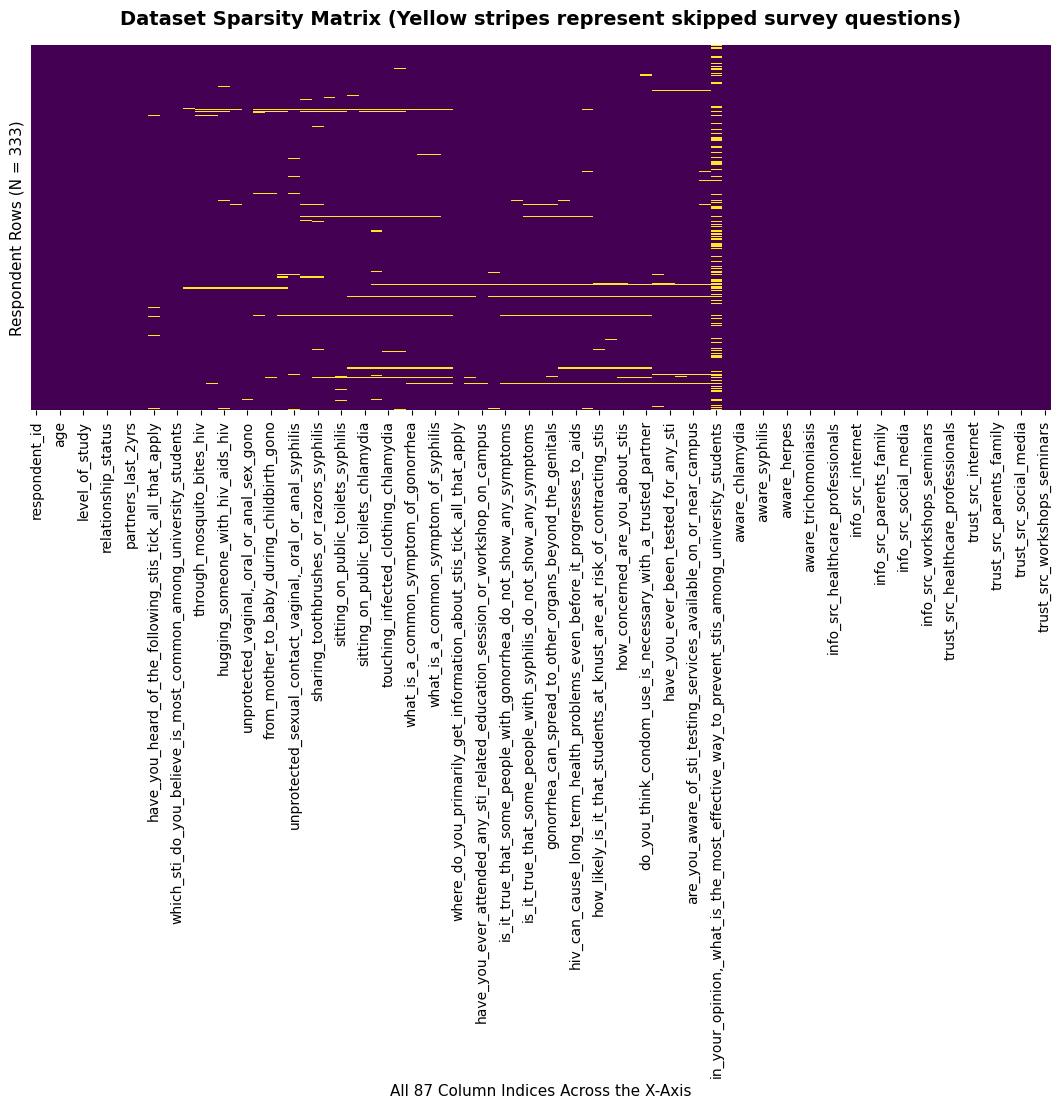

📁 DATA AUDIT: Sparsity matrix successfully written to: ..\reports\dataset_sparsity_matrix.png


In [7]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate and calculate missing percentages per column to audit data completeness
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
null_frame = pd.DataFrame({'Missing Counts': missing_data, 'Percentage (%)': missing_pct})
null_frame = null_frame[null_frame['Missing Counts'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("======= FEATURES WITH NULL RESPONSES =======")
if null_frame.empty:
    print("Perfect dataset structure: Zero missing data points found.")
else:
    print(null_frame.head(10)) # Displays the top 10 attributes with missing values
print("============================================")

# 2. Visualize missing data density matrix using a high-contrast heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title("Dataset Sparsity Matrix (Yellow stripes represent skipped survey questions)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("All 87 Column Indices Across the X-Axis", fontsize=11)
plt.ylabel("Respondent Rows (N = 333)", fontsize=11)

# Apply explicit adjustment to prevent the UserWarning tight_layout clipping
plt.subplots_adjust(top=0.88, bottom=0.15, left=0.10, right=0.95)

# 3. CRITICAL FIX: Save the canvas memory to disk BEFORE calling plt.show()
report_dir = os.path.join("..", "reports")
os.makedirs(report_dir, exist_ok=True)
save_path = os.path.join(report_dir, "dataset_sparsity_matrix.png")
plt.savefig(save_path, dpi=300)

# 4. Render and flush canvas memory last
plt.show()
print(f"📁 DATA AUDIT: Sparsity matrix successfully written to: {save_path}")